In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime

In [12]:
# Leer y parsear el archivo log
def cargar_datos(path):
    with open(path, encoding='utf-8') as f:
        lineas = f.readlines()

    registros = []
    for linea in lineas:
        match = re.match(r"- (\d{4}-\d{2}-\d{2} \d{2}:\d{2}) \| ([\d.]+) min \| (.+)", linea.strip())
        if match:
            fecha = datetime.strptime(match[1], '%Y-%m-%d %H:%M')
            minutos = float(match[2])
            estado = match[3]
            registros.append((fecha, minutos, estado))

    df = pd.DataFrame(registros, columns=["fecha", "minutos", "estado"])
    df["hora"] = df["fecha"].dt.hour
    df["dia_semana"] = df["fecha"].dt.day_name()
    return df

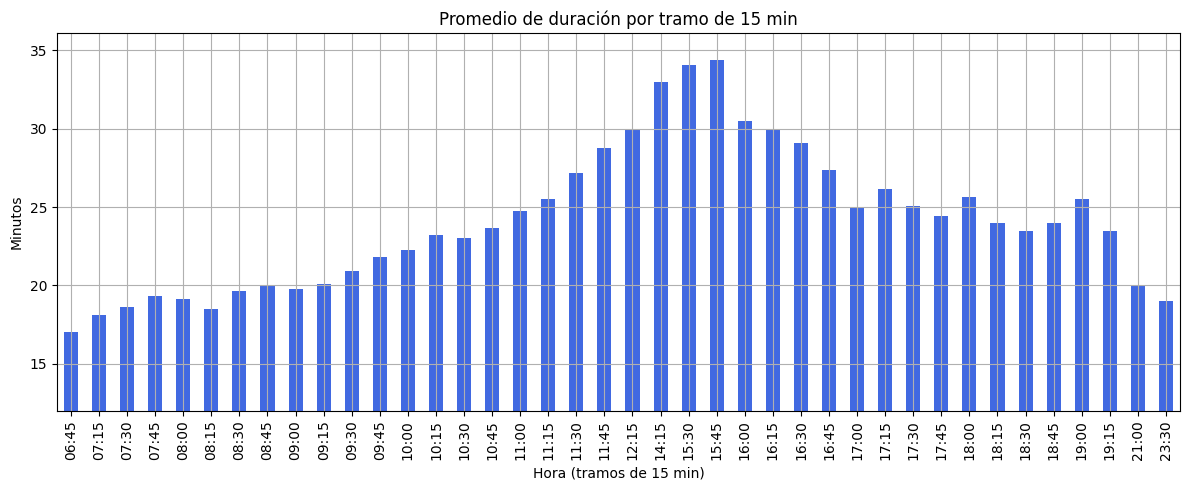

In [13]:
# Cargar datos
df = cargar_datos("trafico_log_mlg.md")

# Crear columna de tramos de 15 min
df["hora_15min"] = df["fecha"].dt.strftime("%H:%M").apply(
    lambda x: f"{x[:2]}:{int(x[3:])//15*15:02d}"
)

# Gráfico 1: duración por tramo de 15 min
min_y = max(0, df.groupby("hora_15min")["minutos"].mean().min() - 5)
plt.figure(figsize=(12, 5))
df.groupby("hora_15min")["minutos"].mean().plot(kind="bar", color="royalblue")
plt.title("Promedio de duración por tramo de 15 min")
plt.ylabel("Minutos")
plt.xlabel("Hora (tramos de 15 min)")
plt.ylim(min_y, None)  # Ajusta el mínimo automáticamente
plt.grid(True)
plt.tight_layout()
plt.show()

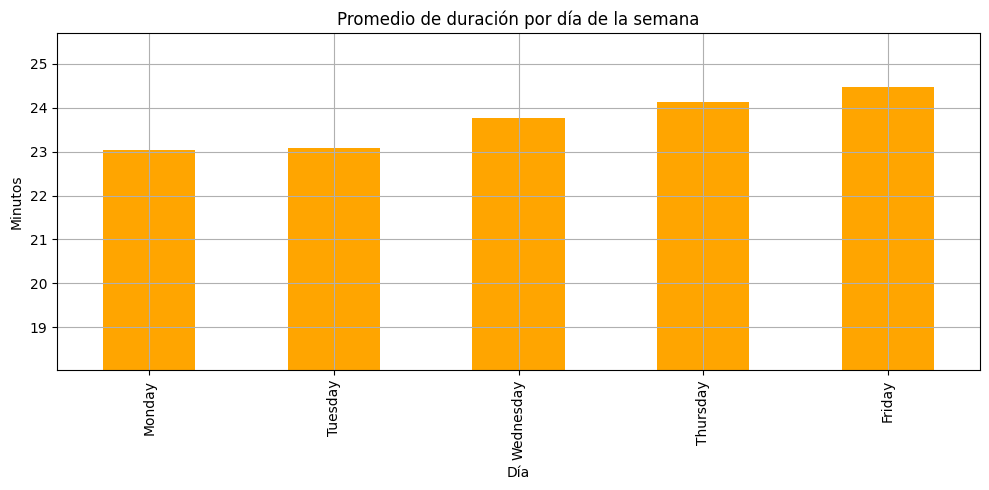

In [14]:
# Gráfico 2: promedio por día de la semana
min_y_dia = max(0, df.groupby("dia_semana")["minutos"].mean().min() - 5)
plt.figure(figsize=(10, 5))
dias_orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
df.groupby("dia_semana")["minutos"].mean().reindex(dias_orden).plot(kind="bar", color="orange")
plt.title("Promedio de duración por día de la semana")
plt.ylabel("Minutos")
plt.xlabel("Día")
plt.ylim(min_y_dia, None)  # Ajusta el mínimo automáticamente
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Mostrar picos de tráfico
picos = df[df["minutos"] > 15].copy()
picos["fecha_str"] = picos["fecha"].dt.strftime('%Y-%m-%d %H:%M')
picos["minutos"] = picos["minutos"].astype(int) 
print("🔺 Registros con tráfico alto (>20min):")
display(picos[["fecha_str", "minutos", "estado"]])

🔺 Registros con tráfico alto (>20min):


,fecha_str,minutos,estado
0,2025-07-22 17:35,27,🚨 ALTO | 🚫 Sin peaje
1,2025-07-22 17:37,27,🚨 ALTO | 🚫 Sin peaje
2,2025-07-22 15:37,27,🚨 ALTO | 🚫 Sin peaje
3,2025-07-22 15:44,25,🚨 ALTO | 🚫 Sin peaje
4,2025-07-22 15:55,24,🚨 ALTO | 🚫 Sin peaje
...,...,...,...
264,2025-08-08 07:23,18,✅ NORMAL | 🚫 Sin peaje
265,2025-08-08 07:48,19,✅ NORMAL | 🚫 Sin peaje
266,2025-08-08 07:48,19,✅ NORMAL | 🚫 Sin peaje
267,2025-08-08 08:00,19,✅ NORMAL | 🚫 Sin peaje
